#**EMIPredict AI - Intelligent Financial Risk Assessment Platform**

#Phase -1:  Data Loading and Preprocessing

## Data Loading & Preprocessing

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
csv_path = '/content/drive/MyDrive/Labmentrix/Projects/Project-3/emi_prediction_dataset.csv'
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
df.head()

/tmp/ipykernel_2258/2076033074.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Shape: (404800, 27)

Columns:
 ['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'years_of_employment', 'company_type', 'house_type', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'existing_loans', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario', 'requested_amount', 'requested_tenure', 'emi_eligibility', 'max_monthly_emi']

Dtypes:
 age                        object
gender                     object
marital_status             object
education                  object
monthly_salary             object
employment_type            object
years_of_employment       float64
company_type               object
house_type                 object
monthly_rent              float64
family_size                 int64
dependents                  int64
school_fees               float64
college_fees              float64
travel_expenses 

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [8]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_summary[missing_summary['missing_count'] > 0])

# Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

                missing_count  missing_pct
education                2404     0.593874
monthly_rent             2426     0.599308
credit_score             2420     0.597826
bank_balance             2426     0.599308
emergency_fund           2351     0.580781

Duplicate rows: 0


In [9]:
for col in ['age', 'monthly_salary', 'bank_balance']:
    # try converting to numeric, invalid entries become NaN
    coerced = pd.to_numeric(df[col], errors='coerce')
    bad_mask = coerced.isnull() & df[col].notnull()  # was non-null but failed to convert
    print(f"\nColumn: {col}")
    print("Non-numeric value examples:", df.loc[bad_mask, col].unique()[:10])
    print("Count of non-numeric entries:", bad_mask.sum())


Column: age
Non-numeric value examples: ['58.0.0' '38.0.0' '32.0.0']
Count of non-numeric entries: 3

Column: monthly_salary
Non-numeric value examples: ['64300.0.0' '23400.0.0.0' '22500.0.0' '22600.0.0' '111900.0.0'
 '86300.0.0' '35200.0.0' '85100.0.0' '55000.0.0' '35300.0.0']
Count of non-numeric entries: 1993

Column: bank_balance
Non-numeric value examples: ['270700.0.0' '232900.0.0' '479700.0.0' '157600.0.0' '561400.0.0'
 '68200.0.0' '102800.0.0' '265900.0.0' '64900.0.0' '162000.0.0']
Count of non-numeric entries: 1966


In [10]:
import re

def fix_numeric_column(series):
    # Extract the leading valid float pattern: digits, optional single decimal point, digits
    extracted = series.astype(str).str.extract(r'^(-?\d+\.?\d*)')[0]
    return pd.to_numeric(extracted, errors='coerce')

for col in ['age', 'monthly_salary', 'bank_balance']:
    before_nulls = df[col].isnull().sum()
    df[col] = fix_numeric_column(df[col])
    after_nulls = df[col].isnull().sum()
    print(f"{col}: dtype now {df[col].dtype}, nulls before={before_nulls}, after={after_nulls}")

age: dtype now float64, nulls before=0, after=0
monthly_salary: dtype now float64, nulls before=0, after=0
bank_balance: dtype now float64, nulls before=2426, after=2440


In [11]:
raw_bank_balance = pd.read_csv(csv_path, usecols=['bank_balance'])['bank_balance']

# Rows that were non-null in raw data but are null after our fix
newly_failed_mask = df['bank_balance'].isnull() & raw_bank_balance.notnull()
print("Count:", newly_failed_mask.sum())
print("Raw values that failed extraction:")
print(raw_bank_balance[newly_failed_mask].unique())

Count: 14
Raw values that failed extraction:
['nan.0']


In [12]:
checks = {
    'age': (df['age'] < 25) | (df['age'] > 60),
    'credit_score': (df['credit_score'] < 300) | (df['credit_score'] > 850),
    'monthly_salary_negative': df['monthly_salary'] < 0,
    'monthly_rent_negative': df['monthly_rent'] < 0,
    'bank_balance_negative': df['bank_balance'] < 0,
    'emergency_fund_negative': df['emergency_fund'] < 0,
    'family_size_invalid': df['family_size'] < 1,
    'dependents_negative': df['dependents'] < 0,
    'requested_tenure_negative': df['requested_tenure'] <= 0,
}

for name, mask in checks.items():
    print(f"{name}: {mask.sum()} violations")

age: 0 violations
credit_score: 4776 violations
monthly_salary_negative: 0 violations
monthly_rent_negative: 0 violations
bank_balance_negative: 0 violations
emergency_fund_negative: 0 violations
family_size_invalid: 0 violations
dependents_negative: 0 violations
requested_tenure_negative: 0 violations


In [13]:
violations = df[(df['credit_score'] < 300) | (df['credit_score'] > 850)]['credit_score']

print("Min:", violations.min())
print("Max:", violations.max())
print("Count below 300:", (violations < 300).sum())
print("Count above 850:", (violations > 850).sum())
print("\nSample below 300:", sorted(violations[violations < 300].unique())[:10])
print("Sample above 850:", sorted(violations[violations > 850].unique())[-10:])

Min: 0.0
Max: 1200.0
Count below 300: 1566
Count above 850: 3210

Sample below 300: [np.float64(0.0)]
Sample above 850: [np.float64(999.0), np.float64(1200.0)]


In [14]:
print(df['credit_score'].value_counts().loc[[0.0, 999.0, 1200.0]])

credit_score
0.0       1566
999.0     1582
1200.0    1628
Name: count, dtype: int64


In [15]:
df['credit_score'] = df['credit_score'].replace([0.0, 999.0, 1200.0], pd.NA)
df['credit_score'] = pd.to_numeric(df['credit_score'], errors='coerce')

In [16]:
df['credit_score'] = df['credit_score'].replace([0.0, 999.0, 1200.0], pd.NA)
df['credit_score'] = pd.to_numeric(df['credit_score'], errors='coerce')

print("credit_score missing now:", df['credit_score'].isnull().sum())
print("credit_score range now:", df['credit_score'].min(), "-", df['credit_score'].max())

credit_score missing now: 7196
credit_score range now: 407.0 - 850.0


In [17]:
print("emi_eligibility distribution:")
print(df['emi_eligibility'].value_counts())
print(df['emi_eligibility'].value_counts(normalize=True) * 100)

print("\nemi_scenario distribution:")
print(df['emi_scenario'].value_counts())

emi_eligibility distribution:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64
emi_eligibility
Not_Eligible    77.289526
Eligible        18.390316
High_Risk        4.320158
Name: proportion, dtype: float64

emi_scenario distribution:
emi_scenario
Home Appliances EMI        80988
Personal Loan EMI          80980
E-commerce Shopping EMI    80948
Education EMI              80942
Vehicle EMI                80942
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['emi_eligibility'], random_state=42
)

# Second split: split temp into 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['emi_eligibility'], random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

# Confirm stratification held
print("\nTrain class %:\n", train_df['emi_eligibility'].value_counts(normalize=True) * 100)
print("\nTest class %:\n", test_df['emi_eligibility'].value_counts(normalize=True) * 100)

Train: (283360, 27)
Val: (60720, 27)
Test: (60720, 27)

Train class %:
 emi_eligibility
Not_Eligible    77.289314
Eligible        18.390387
High_Risk        4.320299
Name: proportion, dtype: float64

Test class %:
 emi_eligibility
Not_Eligible    77.289196
Eligible        18.390975
High_Risk        4.319829
Name: proportion, dtype: float64


In [19]:
# Compute imputation values from train set ONLY
impute_values = {
    'education': train_df['education'].mode()[0],
    'monthly_rent': train_df['monthly_rent'].median(),
    'credit_score': train_df['credit_score'].median(),
    'bank_balance': train_df['bank_balance'].median(),
    'emergency_fund': train_df['emergency_fund'].median(),
}

print("Imputation values computed from train set:")
for col, val in impute_values.items():
    print(f"  {col}: {val}")

# Apply to all three splits
for split_df in [train_df, val_df, test_df]:
    for col, val in impute_values.items():
        split_df[col] = split_df[col].fillna(val)

# Confirm no missing values remain anywhere
print("\nMissing values remaining:")
print("Train:", train_df.isnull().sum().sum())
print("Val:", val_df.isnull().sum().sum())
print("Test:", test_df.isnull().sum().sum())

Imputation values computed from train set:
  education: Graduate
  monthly_rent: 0.0
  credit_score: 700.0
  bank_balance: 196100.0
  emergency_fund: 74200.0

Missing values remaining:
Train: 0
Val: 0
Test: 0


In [20]:
import os

output_dir = '/content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data'
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(f'{output_dir}/train.csv', index=False)
val_df.to_csv(f'{output_dir}/val.csv', index=False)
test_df.to_csv(f'{output_dir}/test.csv', index=False)

print("Saved:")
print(f"  {output_dir}/train.csv  -> {train_df.shape}")
print(f"  {output_dir}/val.csv    -> {val_df.shape}")
print(f"  {output_dir}/test.csv   -> {test_df.shape}")

Saved:
  /content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data/train.csv  -> (283360, 27)
  /content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data/val.csv    -> (60720, 27)
  /content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data/test.csv   -> (60720, 27)


In [21]:
import json

with open(f'{output_dir}/impute_values.json', 'w') as f:
    json.dump(impute_values, f, indent=2)

print("Saved impute_values.json")

Saved impute_values.json


# Phase-2 Exploratory Data Analysis

In [22]:
sns.set_style('whitegrid')

data_dir = '/content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data'
train_df = pd.read_csv(f'{data_dir}/train.csv')

print("Shape:", train_df.shape)
train_df.describe(include='all').T

Shape: (283360, 27)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,283360.0,NaN,NaN,NaN,38.881416,9.307225,26.0,32.0,38.0,48.0,59.0
gender,283360,8,Male,166241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,283360,2,Married,215435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,283360,4,Graduate,128350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_salary,283360.0,NaN,NaN,NaN,59470.186042,43371.129674,3967.0,35400.0,51600.0,72900.0,499970.0
employment_type,283360,3,Private,198270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_of_employment,283360.0,NaN,NaN,NaN,5.358999,6.067157,0.5,1.2,3.2,7.2,36.0
company_type,283360,5,Large Indian,84817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_type,283360,3,Rented,113062,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_rent,283360.0,NaN,NaN,NaN,5787.328758,8628.869393,0.0,0.0,0.0,10500.0,80000.0


In [23]:
categorical_cols = ['gender', 'marital_status', 'education', 'employment_type',
                     'company_type', 'house_type', 'existing_loans',
                     'emi_scenario', 'emi_eligibility']

for col in categorical_cols:
    print(f"\n{col} ({train_df[col].nunique()} unique):")
    print(train_df[col].value_counts())


gender (8 unique):
gender
Male      166241
Female    110860
MALE        1294
male        1282
M           1253
FEMALE       820
F            810
female       800
Name: count, dtype: int64

marital_status (2 unique):
marital_status
Married    215435
Single      67925
Name: count, dtype: int64

education (4 unique):
education
Graduate         128350
Post Graduate     70267
High School       42519
Professional      42224
Name: count, dtype: int64

employment_type (3 unique):
employment_type
Private          198270
Government        56739
Self-employed     28351
Name: count, dtype: int64

company_type (5 unique):
company_type
Large Indian    84817
Mid-size        70920
MNC             70905
Startup         42502
Small           14216
Name: count, dtype: int64

house_type (3 unique):
house_type
Rented    113062
Own        99720
Family     70578
Name: count, dtype: int64

existing_loans (2 unique):
existing_loans
No     170068
Yes    113292
Name: count, dtype: int64

emi_scenario (5 unique)

In [24]:
gender_map = {
    'Male': 'Male', 'MALE': 'Male', 'male': 'Male', 'M': 'Male',
    'Female': 'Female', 'FEMALE': 'Female', 'female': 'Female', 'F': 'Female',
}

data_dir = '/content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data'

val_df = pd.read_csv(f'{data_dir}/val.csv')
test_df = pd.read_csv(f'{data_dir}/test.csv')

for split_df in [train_df, val_df, test_df]:
    split_df['gender'] = split_df['gender'].map(gender_map)

# Confirm fix
print("Train gender:\n", train_df['gender'].value_counts())
print("\nAny nulls introduced?", train_df['gender'].isnull().sum(),
      val_df['gender'].isnull().sum(), test_df['gender'].isnull().sum())

# Re-save all three
train_df.to_csv(f'{data_dir}/train.csv', index=False)
val_df.to_csv(f'{data_dir}/val.csv', index=False)
test_df.to_csv(f'{data_dir}/test.csv', index=False)
print("\nRe-saved train/val/test with cleaned gender column.")

Train gender:
 gender
Male      170070
Female    113290
Name: count, dtype: int64

Any nulls introduced? 0 0 0

Re-saved train/val/test with cleaned gender column.


emi_eligibility          Eligible  High_Risk  Not_Eligible
emi_scenario                                              
E-commerce Shopping EMI      26.3        4.9          68.7
Education EMI                17.8        4.8          77.4
Home Appliances EMI          26.0        5.2          68.8
Personal Loan EMI            11.4        3.4          85.2
Vehicle EMI                  10.5        3.3          86.3


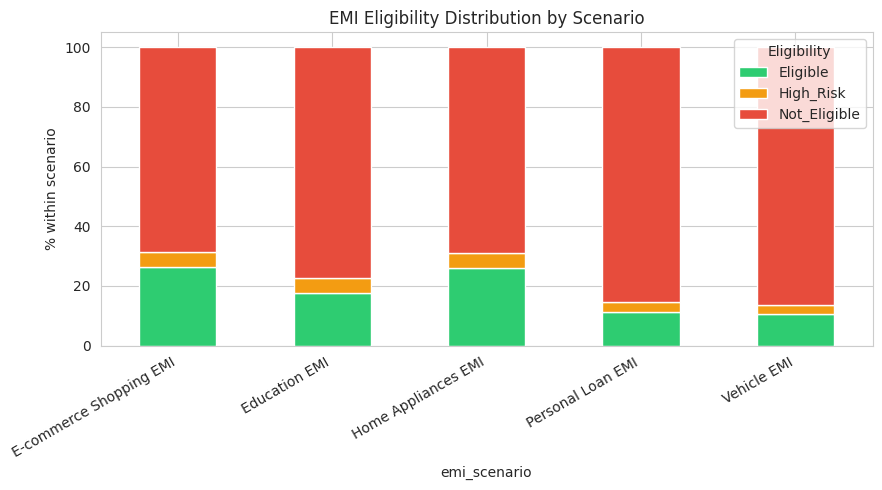

In [25]:
ct = pd.crosstab(train_df['emi_scenario'], train_df['emi_eligibility'], normalize='index') * 100
print(ct.round(1))

ct.plot(kind='bar', stacked=True, figsize=(9, 5), color=['#2ecc71', '#f39c12', '#e74c3c'])
plt.ylabel('% within scenario')
plt.title('EMI Eligibility Distribution by Scenario')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Eligibility')
plt.tight_layout()
plt.show()

In [26]:
numeric_cols = ['age', 'monthly_salary', 'years_of_employment', 'credit_score',
                 'bank_balance', 'emergency_fund', 'current_emi_amount',
                 'requested_amount', 'requested_tenure']

summary = train_df.groupby('emi_eligibility')[numeric_cols].mean().round(1)
print(summary.T)

emi_eligibility      Eligible  High_Risk  Not_Eligible
age                      38.9       38.9          38.9
monthly_salary        78872.6    70397.6       54242.7
years_of_employment       5.6        5.5           5.3
credit_score            725.0      716.0         693.5
bank_balance         338053.2   293012.9      215337.7
emergency_fund       135215.7   118109.5       86217.2
current_emi_amount     2383.1     3031.2        5139.9
requested_amount     155369.1   261783.1      428465.5
requested_tenure         29.7       30.2          29.0


In [27]:
train_df['loan_to_income_ratio'] = train_df['requested_amount'] / train_df['monthly_salary']
train_df['emi_to_income_ratio'] = train_df['current_emi_amount'] / train_df['monthly_salary']

ratio_summary = train_df.groupby('emi_eligibility')[['loan_to_income_ratio', 'emi_to_income_ratio']].mean().round(2)
print(ratio_summary)

                 loan_to_income_ratio  emi_to_income_ratio
emi_eligibility                                           
Eligible                         2.27                 0.03
High_Risk                        4.17                 0.04
Not_Eligible                    10.50                 0.10


/tmp/ipykernel_2258/2494613950.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='emi_eligibility', y='loan_to_income_ratio',


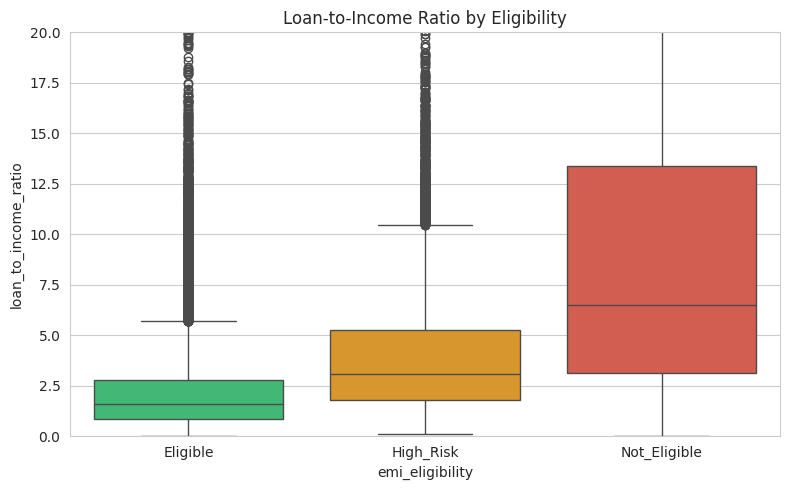

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x='emi_eligibility', y='loan_to_income_ratio',
            order=['Eligible', 'High_Risk', 'Not_Eligible'],
            palette={'Eligible': '#2ecc71', 'High_Risk': '#f39c12', 'Not_Eligible': '#e74c3c'})
plt.ylim(0, 20)  # cap y-axis since there may be extreme outliers
plt.title('Loan-to-Income Ratio by Eligibility')
plt.tight_layout()
plt.show()

In [29]:
corr_cols = ['monthly_salary', 'credit_score', 'bank_balance', 'emergency_fund',
             'current_emi_amount', 'requested_amount', 'loan_to_income_ratio',
             'emi_to_income_ratio', 'max_monthly_emi']

corr = train_df[corr_cols].corr()['max_monthly_emi'].sort_values(ascending=False)
print(corr)

max_monthly_emi         1.000000
bank_balance            0.456584
emergency_fund          0.413797
monthly_salary          0.379251
credit_score            0.299340
requested_amount       -0.002995
loan_to_income_ratio   -0.182073
current_emi_amount     -0.243807
emi_to_income_ratio    -0.289502
Name: max_monthly_emi, dtype: float64


In [30]:
for col in ['employment_type', 'house_type', 'existing_loans']:
    print(f"\n{col}:")
    print(pd.crosstab(train_df[col], train_df['emi_eligibility'], normalize='index').round(3) * 100)


employment_type:
emi_eligibility  Eligible  High_Risk  Not_Eligible
employment_type                                   
Government           21.5        4.7          73.8
Private              17.8        4.2          78.0
Self-employed        16.6        4.2          79.2

house_type:
emi_eligibility  Eligible  High_Risk  Not_Eligible
house_type                                        
Family               24.3        5.4          70.4
Own                  24.3        5.4          70.3
Rented                9.5        2.7          87.7

existing_loans:
emi_eligibility  Eligible  High_Risk  Not_Eligible
existing_loans                                    
No                   25.8        5.6          68.6
Yes                   7.3        2.4          90.4


In [31]:
profile_cols = ['monthly_salary', 'credit_score', 'loan_to_income_ratio',
                 'emi_to_income_ratio', 'current_emi_amount', 'bank_balance']

# Normalize each column 0-1 so we can compare shapes, not just scale
normalized = train_df.groupby('emi_eligibility')[profile_cols].mean()
normalized_scaled = (normalized - normalized.min()) / (normalized.max() - normalized.min())
print(normalized_scaled.loc[['Eligible', 'High_Risk', 'Not_Eligible']].round(2))

# Where does High_Risk credit_score standing come from specifically?
print("\ncredit_score < 650 rate by class:")
print(train_df.groupby('emi_eligibility').apply(lambda g: (g['credit_score'] < 650).mean() * 100).round(1))

print("\nexisting_loans='Yes' rate by class:")
print(pd.crosstab(train_df['emi_eligibility'], train_df['existing_loans'], normalize='index').round(3) * 100)

                 monthly_salary  credit_score  loan_to_income_ratio  \
emi_eligibility                                                       
Eligible                   1.00          1.00                  0.00   
High_Risk                  0.66          0.71                  0.23   
Not_Eligible               0.00          0.00                  1.00   

                 emi_to_income_ratio  current_emi_amount  bank_balance  
emi_eligibility                                                         
Eligible                        0.00                0.00          1.00  
High_Risk                       0.17                0.24          0.63  
Not_Eligible                    1.00                1.00          0.00  

credit_score < 650 rate by class:
emi_eligibility
Eligible        11.5
High_Risk       14.8
Not_Eligible    25.7
dtype: float64

existing_loans='Yes' rate by class:
existing_loans     No   Yes
emi_eligibility            
Eligible         84.2  15.8
High_Risk        78.2  21.8
N

/tmp/ipykernel_2258/4157774742.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(train_df.groupby('emi_eligibility').apply(lambda g: (g['credit_score'] < 650).mean() * 100).round(1))


#Phase-3 Feature Engineering

In [32]:
def engineer_features(df):
    df = df.copy()

    # Total fixed monthly obligations
    df['total_monthly_expenses'] = (
        df['monthly_rent'] + df['school_fees'] + df['college_fees'] +
        df['travel_expenses'] + df['groceries_utilities'] + df['other_monthly_expenses'] +
        df['current_emi_amount']
    )

    # Ratios (add small epsilon to avoid divide-by-zero, though salary min was ~3967 so unlikely)
    df['loan_to_income_ratio'] = df['requested_amount'] / df['monthly_salary']
    df['emi_to_income_ratio'] = df['current_emi_amount'] / df['monthly_salary']
    df['expense_to_income_ratio'] = df['total_monthly_expenses'] / df['monthly_salary']

    # Disposable income = what's left after fixed obligations
    df['disposable_income'] = df['monthly_salary'] - df['total_monthly_expenses']

    return df

train_df = engineer_features(train_df)
val_df = engineer_features(val_df)
test_df = engineer_features(test_df)

print(train_df[['total_monthly_expenses', 'loan_to_income_ratio',
                 'emi_to_income_ratio', 'expense_to_income_ratio',
                 'disposable_income']].describe().round(2))

       total_monthly_expenses  loan_to_income_ratio  emi_to_income_ratio  \
count               283360.00             283360.00            283360.00   
mean                 44613.96                  8.71                 0.08   
std                  23029.32                 11.48                 0.14   
min                   3600.00                  0.02                 0.00   
25%                  28000.00                  2.19                 0.00   
50%                  40500.00                  4.79                 0.00   
75%                  56700.00                 10.85                 0.17   
max                 247800.00                294.56                 7.70   

       expense_to_income_ratio  disposable_income  
count                283360.00          283360.00  
mean                      0.87           14856.22  
std                       0.64           37655.41  
min                       0.01         -161883.00  
25%                       0.61             400.00  
50%

In [33]:
# Does negative disposable income predict eligibility?
train_df['negative_disposable'] = train_df['disposable_income'] < 0
print("Eligibility rate when disposable_income is negative:")
print(pd.crosstab(train_df['negative_disposable'], train_df['emi_eligibility'], normalize='index').round(3) * 100)

# How many rows are extreme outliers on the ratio features?
print("\nRows with loan_to_income_ratio > 50:", (train_df['loan_to_income_ratio'] > 50).sum())
print("Rows with expense_to_income_ratio > 5:", (train_df['expense_to_income_ratio'] > 5).sum())

Eligibility rate when disposable_income is negative:
emi_eligibility      Eligible  High_Risk  Not_Eligible
negative_disposable                                   
False                    24.0        5.6          70.4
True                      0.8        0.2          99.0

Rows with loan_to_income_ratio > 50: 3534
Rows with expense_to_income_ratio > 5: 1204


In [34]:
def add_risk_and_transforms(df):
    df = df.copy()

    # Simple composite risk score: higher = riskier
    # Normalize credit_score contribution (inverted: lower score = more risk)
    df['credit_risk_component'] = (850 - df['credit_score']) / (850 - 300)
    df['existing_loan_flag'] = (df['existing_loans'] == 'Yes').astype(int)
    df['employment_stability'] = df['years_of_employment'].clip(upper=10) / 10  # cap benefit at 10 yrs

    df['risk_score'] = (
        0.4 * df['credit_risk_component'] +
        0.3 * df['existing_loan_flag'] +
        0.3 * (1 - df['employment_stability'])
    )

    # Log-transform skewed ratios (log1p handles 0 values safely)
    df['log_loan_to_income_ratio'] = np.log1p(df['loan_to_income_ratio'])
    df['log_expense_to_income_ratio'] = np.log1p(df['expense_to_income_ratio'])

    return df

import numpy as np

train_df = add_risk_and_transforms(train_df)
val_df = add_risk_and_transforms(val_df)
test_df = add_risk_and_transforms(test_df)

print(train_df[['risk_score', 'log_loan_to_income_ratio', 'log_expense_to_income_ratio']].describe().round(3))

# Quick check: does risk_score actually separate classes?
print("\nrisk_score by eligibility:")
print(train_df.groupby('emi_eligibility')['risk_score'].mean().round(3))

       risk_score  log_loan_to_income_ratio  log_expense_to_income_ratio
count  283360.000                283360.000                   283360.000
mean        0.400                     1.845                        0.597
std         0.202                     0.891                        0.206
min         0.000                     0.022                        0.011
25%         0.268                     1.161                        0.474
50%         0.379                     1.756                        0.576
75%         0.577                     2.472                        0.689
max         0.895                     5.689                        3.475

risk_score by eligibility:
emi_eligibility
Eligible        0.305
High_Risk       0.331
Not_Eligible    0.427
Name: risk_score, dtype: float64


In [35]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Ordinal encoding for education
education_order = {'High School': 0, 'Graduate': 1, 'Post Graduate': 2, 'Professional': 3}
for split_df in [train_df, val_df, test_df]:
    split_df['education_encoded'] = split_df['education'].map(education_order)

# One-hot encoding for nominal categoricals — fit ONLY on train
nominal_cols = ['gender', 'marital_status', 'employment_type', 'company_type',
                 'house_type', 'existing_loans', 'emi_scenario']

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(train_df[nominal_cols])

def apply_ohe(df):
    encoded = ohe.transform(df[nominal_cols])
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_cols), index=df.index)
    return pd.concat([df, encoded_df], axis=1)

train_df = apply_ohe(train_df)
val_df = apply_ohe(val_df)
test_df = apply_ohe(test_df)

# Label encode the classification target — fit on train only
target_encoder = LabelEncoder()
target_encoder.fit(train_df['emi_eligibility'])
for split_df in [train_df, val_df, test_df]:
    split_df['emi_eligibility_encoded'] = target_encoder.transform(split_df['emi_eligibility'])

print("Target mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))
print("\nNew shape:", train_df.shape)
print("\nNew one-hot columns:", [c for c in train_df.columns if any(c.startswith(nc) for nc in nominal_cols)])

Target mapping: {'Eligible': np.int64(0), 'High_Risk': np.int64(1), 'Not_Eligible': np.int64(2)}

New shape: (283360, 56)

New one-hot columns: ['gender', 'marital_status', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario', 'gender_Male', 'marital_status_Single', 'employment_type_Private', 'employment_type_Self-employed', 'company_type_MNC', 'company_type_Mid-size', 'company_type_Small', 'company_type_Startup', 'house_type_Own', 'house_type_Rented', 'existing_loans_Yes', 'emi_scenario_Education EMI', 'emi_scenario_Home Appliances EMI', 'emi_scenario_Personal Loan EMI', 'emi_scenario_Vehicle EMI']


In [36]:
from sklearn.preprocessing import StandardScaler

numeric_features_to_scale = [
    'age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size',
    'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
    'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance',
    'emergency_fund', 'requested_amount', 'requested_tenure', 'total_monthly_expenses',
    'log_loan_to_income_ratio', 'log_expense_to_income_ratio', 'emi_to_income_ratio',
    'expense_to_income_ratio', 'disposable_income', 'risk_score', 'education_encoded'
]

scaler = StandardScaler()
scaler.fit(train_df[numeric_features_to_scale])

for split_df in [train_df, val_df, test_df]:
    scaled = scaler.transform(split_df[numeric_features_to_scale])
    scaled_cols = [f'{c}_scaled' for c in numeric_features_to_scale]
    split_df[scaled_cols] = scaled

print("Final shape:", train_df.shape)

# Save engineered datasets
data_dir = '/content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data'
train_df.to_csv(f'{data_dir}/train_engineered.csv', index=False)
val_df.to_csv(f'{data_dir}/val_engineered.csv', index=False)
test_df.to_csv(f'{data_dir}/test_engineered.csv', index=False)
print("Saved engineered train/val/test to", data_dir)

Final shape: (283360, 81)
Saved engineered train/val/test to /content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data


#Phase-4: Model Development

In [37]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [38]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# SQLite-backed tracking store, persisted on Drive so it survives Colab restarts
tracking_dir = '/content/drive/MyDrive/Labmentrix/Projects/Project-3'
mlflow.set_tracking_uri(f'sqlite:///{tracking_dir}/mlflow.db')
mlflow.set_experiment('EMIPredict_Classification')

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:////content/drive/MyDrive/Labmentrix/Projects/Project-3/mlflow.db


In [39]:
exclude_cols = [
    'emi_eligibility', 'emi_eligibility_encoded', 'max_monthly_emi',
    'gender', 'marital_status', 'education', 'employment_type', 'company_type',
    'house_type', 'existing_loans', 'emi_scenario', 'negative_disposable'
]

tree_features = [c for c in train_df.columns
                  if c not in exclude_cols and not c.endswith('_scaled')]

scaled_numeric = [c for c in train_df.columns if c.endswith('_scaled')]
linear_features = scaled_numeric + [c for c in tree_features if c.startswith(
    ('gender_', 'marital_status_', 'employment_type_', 'company_type_',
     'house_type_', 'existing_loans_', 'emi_scenario_'))]

print("Tree feature count:", len(tree_features))
print("Linear feature count:", len(linear_features))
print("\nTree features:", tree_features)

Tree feature count: 44
Linear feature count: 40

Tree features: ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'loan_to_income_ratio', 'emi_to_income_ratio', 'total_monthly_expenses', 'expense_to_income_ratio', 'disposable_income', 'credit_risk_component', 'existing_loan_flag', 'employment_stability', 'risk_score', 'log_loan_to_income_ratio', 'log_expense_to_income_ratio', 'education_encoded', 'gender_Male', 'marital_status_Single', 'employment_type_Private', 'employment_type_Self-employed', 'company_type_MNC', 'company_type_Mid-size', 'company_type_Small', 'company_type_Startup', 'house_type_Own', 'house_type_Rented', 'existing_loans_Yes', 'emi_scenario_Education EMI', 'emi_scenario_Home Appliances EMI', 'emi_scenario_Personal Loan

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, classification_report

# Build X/y for classification
X_train_linear = train_df[linear_features]
y_train = train_df['emi_eligibility_encoded']

X_val_linear = val_df[linear_features]
y_val = val_df['emi_eligibility_encoded']

with mlflow.start_run(run_name='logistic_regression_baseline'):
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train_linear, y_train)

    preds = model.predict(X_val_linear)
    proba = model.predict_proba(X_val_linear)

    acc = accuracy_score(y_val, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, preds, average='macro')
    auc = roc_auc_score(y_val, proba, multi_class='ovr')

    mlflow.log_param('model_type', 'LogisticRegression')
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('macro_precision', precision)
    mlflow.log_metric('macro_recall', recall)
    mlflow.log_metric('macro_f1', f1)
    mlflow.log_metric('roc_auc_ovr', auc)
    mlflow.sklearn.log_model(model, 'model')

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision/Recall/F1: {precision:.4f} / {recall:.4f} / {f1:.4f}")
    print(f"ROC-AUC (OVR): {auc:.4f}")
    print("\n", classification_report(y_val, preds, target_names=target_encoder.classes_))

2026/08/26 08:34:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.8352
Macro Precision/Recall/F1: 0.6956 / 0.8129 / 0.6885
ROC-AUC (OVR): 0.9562

               precision    recall  f1-score   support

    Eligible       0.90      0.78      0.84     11166
   High_Risk       0.19      0.81      0.31      2623
Not_Eligible       0.99      0.85      0.92     46931

    accuracy                           0.84     60720
   macro avg       0.70      0.81      0.69     60720
weighted avg       0.94      0.84      0.88     60720



In [41]:
from sklearn.ensemble import RandomForestClassifier

X_train_tree = train_df[tree_features]
X_val_tree = val_df[tree_features]

with mlflow.start_run(run_name='random_forest_classifier'):
    model_rf = RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    model_rf.fit(X_train_tree, y_train)

    preds = model_rf.predict(X_val_tree)
    proba = model_rf.predict_proba(X_val_tree)

    acc = accuracy_score(y_val, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, preds, average='macro')
    auc = roc_auc_score(y_val, proba, multi_class='ovr')

    mlflow.log_param('model_type', 'RandomForestClassifier')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 15)
    mlflow.log_param('class_weight', 'balanced')
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('macro_precision', precision)
    mlflow.log_metric('macro_recall', recall)
    mlflow.log_metric('macro_f1', f1)
    mlflow.log_metric('roc_auc_ovr', auc)
    mlflow.sklearn.log_model(model_rf, 'model')

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision/Recall/F1: {precision:.4f} / {recall:.4f} / {f1:.4f}")
    print(f"ROC-AUC (OVR): {auc:.4f}")
    print("\n", classification_report(y_val, preds, target_names=target_encoder.classes_))

    # Feature importance - top 10
    importances = pd.Series(model_rf.feature_importances_, index=tree_features).sort_values(ascending=False)
    print("\nTop 10 feature importances:\n", importances.head(10))

2026/08/26 08:36:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.9063
Macro Precision/Recall/F1: 0.7297 / 0.8215 / 0.7514
ROC-AUC (OVR): 0.9708

               precision    recall  f1-score   support

    Eligible       0.91      0.87      0.89     11166
   High_Risk       0.29      0.66      0.41      2623
Not_Eligible       0.99      0.93      0.96     46931

    accuracy                           0.91     60720
   macro avg       0.73      0.82      0.75     60720
weighted avg       0.94      0.91      0.92     60720


Top 10 feature importances:
 log_loan_to_income_ratio       0.117337
requested_tenure               0.113700
loan_to_income_ratio           0.112639
disposable_income              0.110064
expense_to_income_ratio        0.093657
log_expense_to_income_ratio    0.088246
requested_amount               0.076478
monthly_salary                 0.027676
risk_score                     0.020416
bank_balance                   0.016770
dtype: float64


In [42]:
from xgboost import XGBClassifier

# XGBoost doesn't have class_weight='balanced'; compute sample weights manually
class_counts = y_train.value_counts()
total = len(y_train)
class_weights = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}
sample_weights = y_train.map(class_weights)

with mlflow.start_run(run_name='xgboost_classifier'):
    model_xgb = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=3,
        random_state=42, n_jobs=-1, eval_metric='mlogloss'
    )
    model_xgb.fit(X_train_tree, y_train, sample_weight=sample_weights)

    preds = model_xgb.predict(X_val_tree)
    proba = model_xgb.predict_proba(X_val_tree)

    acc = accuracy_score(y_val, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, preds, average='macro')
    auc = roc_auc_score(y_val, proba, multi_class='ovr')

    mlflow.log_param('model_type', 'XGBClassifier')
    mlflow.log_param('n_estimators', 300)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('macro_precision', precision)
    mlflow.log_metric('macro_recall', recall)
    mlflow.log_metric('macro_f1', f1)
    mlflow.log_metric('roc_auc_ovr', auc)
    mlflow.xgboost.log_model(model_xgb, 'model')

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision/Recall/F1: {precision:.4f} / {recall:.4f} / {f1:.4f}")
    print(f"ROC-AUC (OVR): {auc:.4f}")
    print("\n", classification_report(y_val, preds, target_names=target_encoder.classes_))

ERROR:pyngrok.process.ngrok:t=2026-08-26T08:36:51+0000 lvl=eror msg="heartbeat timeout, terminating session" obj=tunnels.session obj=csess id=1c3301817ff0 clientid=1743bb40f5b98b35cf944506fbce21c5
ERROR:pyngrok.process.ngrok:t=2026-08-26T08:36:51+0000 lvl=eror msg="session closed, starting reconnect loop" obj=tunnels.session obj=csess id=7e9f25d9114b err="session closed"
2026/08/26 08:37:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.9335
Macro Precision/Recall/F1: 0.7910 / 0.9269 / 0.8220
ROC-AUC (OVR): 0.9907

               precision    recall  f1-score   support

    Eligible       0.98      0.91      0.94     11166
   High_Risk       0.40      0.93      0.56      2623
Not_Eligible       1.00      0.94      0.97     46931

    accuracy                           0.93     60720
   macro avg       0.79      0.93      0.82     60720
weighted avg       0.97      0.93      0.95     60720



In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mlflow.set_experiment('EMIPredict_Regression')

y_train_reg = train_df['max_monthly_emi']
y_val_reg = val_df['max_monthly_emi']

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

with mlflow.start_run(run_name='linear_regression_baseline'):
    model_lr = LinearRegression()
    model_lr.fit(X_train_linear, y_train_reg)

    preds = model_lr.predict(X_val_linear)

    rmse = np.sqrt(mean_squared_error(y_val_reg, preds))
    mae = mean_absolute_error(y_val_reg, preds)
    r2 = r2_score(y_val_reg, preds)
    mape_val = mape(y_val_reg, preds)

    mlflow.log_param('model_type', 'LinearRegression')
    mlflow.log_metric('rmse', rmse)
    mlflow.log_metric('mae', mae)
    mlflow.log_metric('r2', r2)
    mlflow.log_metric('mape', mape_val)
    mlflow.sklearn.log_model(model_lr, 'model')

    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape_val:.2f}%")

2026/08/26 08:37:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RMSE: 4030.12
MAE: 2876.78
R²: 0.7315
MAPE: 194.48%


In [44]:
from sklearn.ensemble import RandomForestRegressor

with mlflow.start_run(run_name='random_forest_regressor'):
    model_rf_reg = RandomForestRegressor(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
    )
    model_rf_reg.fit(X_train_tree, y_train_reg)

    preds = model_rf_reg.predict(X_val_tree)

    rmse = np.sqrt(mean_squared_error(y_val_reg, preds))
    mae = mean_absolute_error(y_val_reg, preds)
    r2 = r2_score(y_val_reg, preds)
    mape_val = mape(y_val_reg, preds)

    mlflow.log_param('model_type', 'RandomForestRegressor')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('max_depth', 15)
    mlflow.log_metric('rmse', rmse)
    mlflow.log_metric('mae', mae)
    mlflow.log_metric('r2', r2)
    mlflow.log_metric('mape', mape_val)
    mlflow.sklearn.log_model(model_rf_reg, 'model')

    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape_val:.2f}%")

    importances = pd.Series(model_rf_reg.feature_importances_, index=tree_features).sort_values(ascending=False)
    print("\nTop 10 feature importances:\n", importances.head(10))

2026/08/26 08:54:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RMSE: 939.96
MAE: 356.71
R²: 0.9854
MAPE: 6.60%

Top 10 feature importances:
 disposable_income          0.834764
risk_score                 0.052216
monthly_salary             0.046528
bank_balance               0.017650
credit_risk_component      0.009970
credit_score               0.009267
groceries_utilities        0.004279
house_type_Rented          0.003144
employment_type_Private    0.002285
years_of_employment        0.002220
dtype: float64


In [45]:
from xgboost import XGBRegressor

with mlflow.start_run(run_name='xgboost_regressor'):
    model_xgb_reg = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1
    )
    model_xgb_reg.fit(X_train_tree, y_train_reg)

    preds = model_xgb_reg.predict(X_val_tree)

    rmse = np.sqrt(mean_squared_error(y_val_reg, preds))
    mae = mean_absolute_error(y_val_reg, preds)
    r2 = r2_score(y_val_reg, preds)
    mape_val = mape(y_val_reg, preds)

    mlflow.log_param('model_type', 'XGBRegressor')
    mlflow.log_param('n_estimators', 300)
    mlflow.log_param('max_depth', 6)
    mlflow.log_param('learning_rate', 0.1)
    mlflow.log_metric('rmse', rmse)
    mlflow.log_metric('mae', mae)
    mlflow.log_metric('r2', r2)
    mlflow.log_metric('mape', mape_val)
    mlflow.xgboost.log_model(model_xgb_reg, 'model')

    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape_val:.2f}%")

2026/08/26 08:54:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RMSE: 667.85
MAE: 265.84
R²: 0.9926
MAPE: 8.29%


In [47]:
import mlflow

client = mlflow.tracking.MlflowClient()

for exp_name in ['EMIPredict_Classification', 'EMIPredict_Regression']:
    exp = client.get_experiment_by_name(exp_name)
    runs = client.search_runs(exp.experiment_id, order_by=['start_time DESC'])

    print(f"\n=== {exp_name} ===")
    rows = []
    for r in runs:
        row = {'run_name': r.data.tags.get('mlflow.runName', ''), **r.data.metrics}
        rows.append(row)
    print(pd.DataFrame(rows).round(4))


=== EMIPredict_Classification ===
                       run_name  accuracy  macro_precision  macro_recall  \
0            xgboost_classifier    0.9335           0.7910        0.9269   
1      random_forest_classifier    0.9063           0.7297        0.8215   
2  logistic_regression_baseline    0.8352           0.6956        0.8129   
3      xgboost_classifier_final       NaN              NaN           NaN   
4            xgboost_classifier    0.9335           0.7910        0.9269   
5      random_forest_classifier    0.9063           0.7297        0.8215   
6  logistic_regression_baseline    0.8352           0.6956        0.8129   
7  logistic_regression_baseline    0.8352           0.6956        0.8129   

   macro_f1  roc_auc_ovr  
0    0.8220       0.9907  
1    0.7514       0.9708  
2    0.6885       0.9562  
3       NaN          NaN  
4    0.8220       0.9907  
5    0.7514       0.9708  
6    0.6885       0.9562  
7    0.6885       0.9562  

=== EMIPredict_Regression ===
      

In [51]:
!pkill -f "mlflow ui"

In [52]:
# Kill any existing mlflow ui process first (the old one is still running on port 5000)
!pkill -f "mlflow ui"

import time
time.sleep(2)  # give it a moment to fully shut down

# Restart with --host 0.0.0.0 so it accepts ngrok's forwarded requests
get_ipython().system_raw(
    'mlflow ui --backend-store-uri sqlite:////content/drive/MyDrive/Labmentrix/Projects/Project-3/mlflow.db '
    '--port 5000 --host 0.0.0.0 &'
)

time.sleep(3)  # give the server a moment to start
print("MLflow UI restarted on 0.0.0.0:5000")

MLflow UI restarted on 0.0.0.0:5000


In [56]:
from pyngrok import ngrok

ngrok.kill()  # clear the old tunnel first

public_url = ngrok.connect(5000, host_header="rewrite")
print("MLflow UI available at:", public_url)

MLflow UI available at: NgrokTunnel: "https://prorate-varnish-splice.ngrok-free.dev" -> "http://localhost:5000"


# Phase-6: Streamlit Application

In [57]:
import joblib
import os

export_dir = '/content/drive/MyDrive/Labmentrix/Projects/Project-3/deployment_artifacts'
os.makedirs(export_dir, exist_ok=True)

# Models
joblib.dump(model_xgb, f'{export_dir}/classifier.pkl')
joblib.dump(model_xgb_reg, f'{export_dir}/regressor.pkl')

# Preprocessing objects
joblib.dump(scaler, f'{export_dir}/scaler.pkl')
joblib.dump(ohe, f'{export_dir}/onehot_encoder.pkl')
joblib.dump(target_encoder, f'{export_dir}/target_encoder.pkl')

# Metadata needed to rebuild the exact same pipeline at inference time
import json
metadata = {
    'tree_features': tree_features,
    'nominal_cols': nominal_cols,
    'education_order': education_order,
    'numeric_features_to_scale': numeric_features_to_scale,
}
with open(f'{export_dir}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Copy the impute_values.json from Phase 1
import shutil
shutil.copy(
    '/content/drive/MyDrive/Labmentrix/Projects/Project-3/cleaned_data/impute_values.json',
    f'{export_dir}/impute_values.json'
)

print("Exported files:")
for f in os.listdir(export_dir):
    print(" -", f)

Exported files:
 - classifier.pkl
 - regressor.pkl
 - scaler.pkl
 - onehot_encoder.pkl
 - target_encoder.pkl
 - metadata.json
 - impute_values.json
